# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

from sklearn.utils import resample

In [4]:
fraud.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [5]:
fraud["fraud"].value_counts(normalize=True)

fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64

In [6]:
features = fraud.drop(columns = ['fraud'])
target = fraud["fraud"]

X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=0, stratify=target)

In [7]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled_np = scaler.transform(X_train)
X_test_scaled_np = scaler.transform(X_test)

In [8]:
log_reg = LogisticRegression()

In [9]:
X_train_scaled_fraud = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
X_test_scaled_fraud  = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)

In [10]:
log_reg.fit(X_train_scaled_fraud, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
log_reg.score(X_test_scaled_fraud, y_test)

0.959012

In [14]:
y_pred = log_reg.predict(X_test_scaled_fraud)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[226550   1599]
 [  8648  13203]]
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98    228149
         1.0       0.89      0.60      0.72     21851

    accuracy                           0.96    250000
   macro avg       0.93      0.80      0.85    250000
weighted avg       0.96      0.96      0.96    250000



#### as we can clearly say above, accuracy is totally misleading. 
#### the recall, which has a value of 60% shows that a lot of frauds are getting undetected
#### so we can say that the model is not good bc it only flags fraud when it is very sure, but that is a real problem bc letting pass false negatives can be really expensive errors.

## Oversampling

In [15]:
train = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)

In [16]:
train["fraud"] = y_train.values

In [17]:
fraud = train[train["fraud"] == 1]
no_fraud = train[train["fraud"] == 0]

In [18]:
len(fraud),len(no_fraud)

(65552, 684448)

In [19]:
yes_oversampled = resample(fraud,
                                    replace=True,  
                                    n_samples = len(no_fraud),  
                                    random_state=0)   

In [20]:
train_over = pd.concat([yes_oversampled, no_fraud])
train_over

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
761717,-0.034693,2.171804,0.560311,0.366483,-0.734528,-0.334463,0.732884,1.0
612815,-0.319198,-0.148740,1.077534,0.366483,1.361418,-0.334463,0.732884,1.0
300510,-0.316171,-0.188226,1.404768,0.366483,-0.734528,-0.334463,0.732884,1.0
806357,-0.310827,-0.177234,1.246225,0.366483,1.361418,-0.334463,0.732884,1.0
661676,1.171157,0.279124,1.670722,0.366483,-0.734528,-0.334463,0.732884,1.0
...,...,...,...,...,...,...,...,...
425653,-0.240915,-0.186914,0.464833,0.366483,-0.734528,-0.334463,-1.364473,0.0
663227,-0.176453,-0.186729,0.143888,0.366483,-0.734528,-0.334463,0.732884,0.0
661920,-0.358337,-0.146922,-0.192134,0.366483,-0.734528,-0.334463,0.732884,0.0
744511,-0.343223,0.473614,-0.590550,0.366483,1.361418,-0.334463,0.732884,0.0


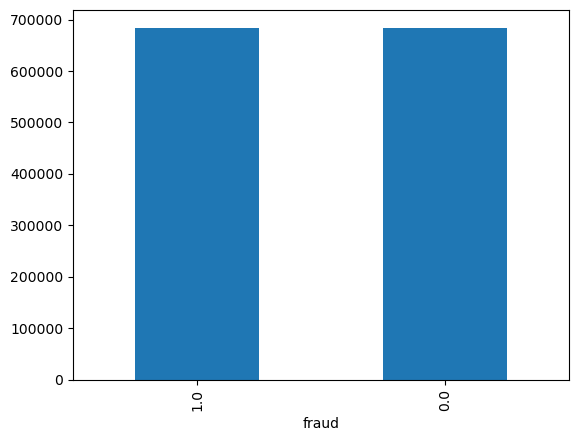

In [21]:
fraud_plt = train_over["fraud"].value_counts()
fraud_plt.plot(kind="bar")
plt.show()


In [22]:
X_train_over = train_over.drop(columns = ["fraud"])
y_train_over = train_over["fraud"]

In [23]:
log_reg = LogisticRegression()
log_reg.fit(X_train_over, y_train_over)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
y_pred_test_log = log_reg.predict(X_test_scaled_fraud)
print(classification_report(y_pred = y_pred_test_log, y_true = y_test))

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    228149
         1.0       0.57      0.95      0.71     21851

    accuracy                           0.93    250000
   macro avg       0.78      0.94      0.84    250000
weighted avg       0.96      0.93      0.94    250000



##### findings:
##### Oversampling raised fraud recall from 0.60 to 0.95, so undetected fraud dropped
##### Accuracy went down (0.96 -> 0.93), which is expected
##### Precision (0.89 -> 0.57)

## Undersampling

In [26]:
no_undersampled = resample(no_fraud,
                           replace=False,              
                           n_samples=len(fraud),       
                           random_state=0)

In [27]:
train_under = pd.concat([no_undersampled, fraud])

In [28]:
X_train_under = train_under.drop(columns=["fraud"])
y_train_under = train_under["fraud"]

In [29]:
log_reg = LogisticRegression()
log_reg.fit(X_train_under, y_train_under)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred_test_log = log_reg.predict(X_test_scaled_fraud)
print(classification_report(y_true=y_test, y_pred=y_pred_test_log))

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    228149
         1.0       0.57      0.95      0.71     21851

    accuracy                           0.93    250000
   macro avg       0.78      0.94      0.84    250000
weighted avg       0.96      0.93      0.94    250000



##### Undersampling gave the same result as oversampling (recall 0.95, precision 0.57)

## SMOTE

In [31]:
from imblearn.over_sampling import SMOTE

In [32]:
sm = SMOTE(random_state = 1,sampling_strategy=1.0)

In [34]:
X_train_sm, y_train_sm =  sm.fit_resample(X_train_scaled_fraud,y_train)

In [35]:
log_reg = LogisticRegression(max_iter=1000)  # às vezes pode ser preciso aumentar o nº de interaçoes
log_reg.fit(X_train_sm, y_train_sm)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
y_pred_test_log = log_reg.predict(X_test_scaled_fraud)
print(classification_report(y_pred = y_pred_test_log, y_true = y_test))

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    228149
         1.0       0.57      0.95      0.71     21851

    accuracy                           0.93    250000
   macro avg       0.78      0.94      0.84    250000
weighted avg       0.96      0.93      0.94    250000

